# Experiment 3 Report

FastMCP-based instructional tool-selection runtime.

This notebook loads the final Exp3-Core run artifacts and produces summary tables and charts for the thesis report. The analysis keeps `Task-TSA` and `Profile-TSA` separate, with `Task-TSA` and `PTS` treated as the primary metrics.

In [1]:
from __future__ import annotations

import json
import os
import sqlite3
from pathlib import Path

import pandas as pd

RUN_ID = "exp3_core_real_20260503_1"
EXP_DIR = Path.cwd()
if EXP_DIR.name != "exp3_mcp_runtime":
    EXP_DIR = Path("experiments/exp3_mcp_runtime")

RUN_DIR = EXP_DIR / "results" / "runs" / RUN_ID
DB_PATH = RUN_DIR / "exp3_runtime_results.db"
METRICS_PATH = RUN_DIR / "exp3_runtime_metrics.json"
FIGURE_DIR = RUN_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(RUN_DIR / ".matplotlib"))

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
palette = {"S0": "#6B7280", "S1a": "#2563EB", "S1b": "#16A34A"}
condition_order = ["S0", "S1a", "S1b"]

print(f"Run directory: {RUN_DIR}")
print(f"DB exists: {DB_PATH.exists()} | Metrics exists: {METRICS_PATH.exists()}")

Run directory: /Users/nyeinchanaung/Documents/GitHub/mcp-rag/experiments/exp3_mcp_runtime/results/runs/exp3_core_real_20260503_1
DB exists: True | Metrics exists: True


In [2]:
with open(METRICS_PATH, "r", encoding="utf-8") as f:
    metrics = json.load(f)

conn = sqlite3.connect(DB_PATH)
sessions = pd.read_sql_query("SELECT * FROM exp3_runtime_sessions", conn)
conn.close()

sessions["task_tsa_hit"] = sessions["task_tsa_hit"].astype(int)
sessions["profile_tsa_hit"] = sessions["profile_tsa_hit"].astype(int)
sessions["profile_eval_eligible"] = sessions["profile_eval_eligible"].astype(int)
sessions["execution_success"] = sessions["execution_success"].astype(int)
sessions["condition"] = pd.Categorical(sessions["condition"], categories=condition_order, ordered=True)

assert len(sessions) == 2880, f"Expected 2880 rows, got {len(sessions)}"
display(sessions.head())

,id,session_id,benchmark,condition,question_id,question_type,query,profile_json,profile_label,selected_tool_id,...,optimal_tool_id,tsa_hit,pts_delta,input_tokens,latency_ms,execution_success,retrieved_evidence_json,final_response,tool_result_json,created_at
0,1,exp3_core:EXP3C_001:Active-Intuitive-Verbal-Gl...,exp3_core,S0,EXP3C_001,concept_explain,Explain what gradient descent is and why the l...,"{""act_ref"": -1, ""sen_int"": 1, ""vis_ver"": 1, ""s...",Active-Intuitive-Verbal-Global,1,...,1,1,0.000000,1492,6976.690167,1,"[{""chunk_id"": ""c63e76c88dcc_0"", ""chapter"": ""hy...",Gradient descent is a fundamental optimization...,"{""tool_id"": 1, ""tool_name"": ""Concept Explainer...",2026-05-03T21:50:34.903561
1,2,exp3_core:EXP3C_001:Active-Intuitive-Verbal-Gl...,exp3_core,S1a,EXP3C_001,concept_explain,Explain what gradient descent is and why the l...,"{""act_ref"": -1, ""sen_int"": 1, ""vis_ver"": 1, ""s...",Active-Intuitive-Verbal-Global,14,...,1,0,94.302949,85,54.317166,1,"[{""chunk_id"": ""c63e76c88dcc_0"", ""chapter"": ""hy...","1. In this chapter, we optimize the validation...","{""tool_id"": 14, ""tool_name"": ""Content Retrieve...",2026-05-03T21:50:35.045549
2,3,exp3_core:EXP3C_001:Active-Intuitive-Verbal-Gl...,exp3_core,S1b,EXP3C_001,concept_explain,Explain what gradient descent is and why the l...,"{""act_ref"": -1, ""sen_int"": 1, ""vis_ver"": 1, ""s...",Active-Intuitive-Verbal-Global,14,...,1,0,94.302949,85,52.850417,1,"[{""chunk_id"": ""c63e76c88dcc_0"", ""chapter"": ""hy...","1. In this chapter, we optimize the validation...","{""tool_id"": 14, ""tool_name"": ""Content Retrieve...",2026-05-03T21:50:35.152856
3,4,exp3_core:EXP3C_001:Active-Intuitive-Verbal-Se...,exp3_core,S0,EXP3C_001,concept_explain,Explain what gradient descent is and why the l...,"{""act_ref"": -1, ""sen_int"": 1, ""vis_ver"": 1, ""s...",Active-Intuitive-Verbal-Sequential,1,...,1,1,0.000000,1492,10635.316542,1,"[{""chunk_id"": ""c63e76c88dcc_0"", ""chapter"": ""hy...",Gradient descent is a fundamental optimization...,"{""tool_id"": 1, ""tool_name"": ""Concept Explainer...",2026-05-03T21:50:46.757469
4,5,exp3_core:EXP3C_001:Active-Intuitive-Verbal-Se...,exp3_core,S1a,EXP3C_001,concept_explain,Explain what gradient descent is and why the l...,"{""act_ref"": -1, ""sen_int"": 1, ""vis_ver"": 1, ""s...",Active-Intuitive-Verbal-Sequential,14,...,1,0,94.302949,85,52.828417,1,"[{""chunk_id"": ""c63e76c88dcc_0"", ""chapter"": ""hy...","1. In this chapter, we optimize the validation...","{""tool_id"": 14, ""tool_name"": ""Content Retrieve...",2026-05-03T21:50:46.891921


## Condition-Level Summary

In [3]:
condition_metrics = (
    sessions.groupby("condition", observed=True)
    .agg(
        n=("session_id", "count"),
        matched_sessions=("session_id", "nunique"),
        task_tsa=("task_tsa_hit", "mean"),
        profile_tsa_all=("profile_tsa_hit", "mean"),
        profile_tsa_eligible=("profile_tsa_hit", lambda s: s[sessions.loc[s.index, "profile_eval_eligible"] == 1].mean()),
        profile_eligible_n=("profile_eval_eligible", "sum"),
        pts=("pts_delta", "mean"),
        execution_success_rate=("execution_success", "mean"),
        latency_ms=("latency_ms", "mean"),
    )
    .reset_index()
)

display(condition_metrics.round(3))

,condition,n,matched_sessions,task_tsa,profile_tsa_all,profile_tsa_eligible,profile_eligible_n,pts,execution_success_rate,latency_ms
0,S0,960,960,0.783,0.725,0.125,64,0.000,1.0,983.126
1,S1a,960,960,0.833,0.819,0.031,64,93.517,1.0,771.617
2,S1b,960,960,0.820,0.818,0.125,64,93.478,1.0,801.684


In [4]:
paired = metrics["benchmarks"]["exp3_core"]["paired"]
paired_df = pd.DataFrame.from_dict(paired, orient="index").reset_index(names="comparison")
display(paired_df[[
    "comparison",
    "task_tsa_delta",
    "profile_tsa_all_delta",
    "profile_tsa_eligible_delta",
    "pts_delta",
    "latency_ms_delta",
    "n_pairs",
    "profile_eligible_n_pairs",
]].round(3))

,comparison,task_tsa_delta,profile_tsa_all_delta,profile_tsa_eligible_delta,pts_delta,latency_ms_delta,n_pairs,profile_eligible_n_pairs
0,S1b_minus_S1a,-0.014,-0.001,0.094,-0.038,30.067,960,64
1,S1b_minus_S0,0.036,0.093,0.000,93.478,-181.442,960,64
2,S1a_minus_S0,0.050,0.094,-0.094,93.517,-211.509,960,64


## Main Accuracy Metrics

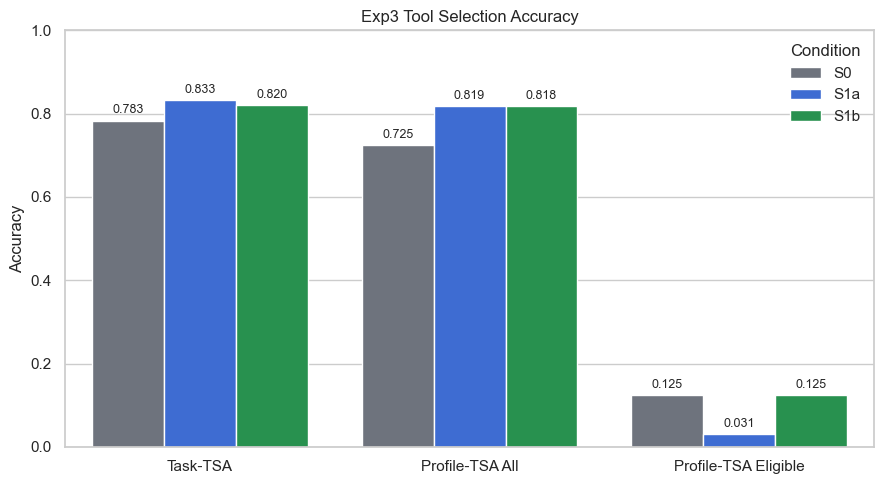

In [5]:
acc_long = condition_metrics.melt(
    id_vars="condition",
    value_vars=["task_tsa", "profile_tsa_all", "profile_tsa_eligible"],
    var_name="metric",
    value_name="score",
)
label_map = {
    "task_tsa": "Task-TSA",
    "profile_tsa_all": "Profile-TSA All",
    "profile_tsa_eligible": "Profile-TSA Eligible",
}
acc_long["metric"] = acc_long["metric"].map(label_map)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=acc_long, x="metric", y="score", hue="condition", palette=palette, ax=ax)
ax.set_ylim(0, 1.0)
ax.set_xlabel("")
ax.set_ylabel("Accuracy")
ax.set_title("Exp3 Tool Selection Accuracy")
ax.legend(title="Condition", frameon=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "exp3_accuracy_metrics.png", dpi=200, bbox_inches="tight")
plt.show()

## Efficiency And Runtime Validity

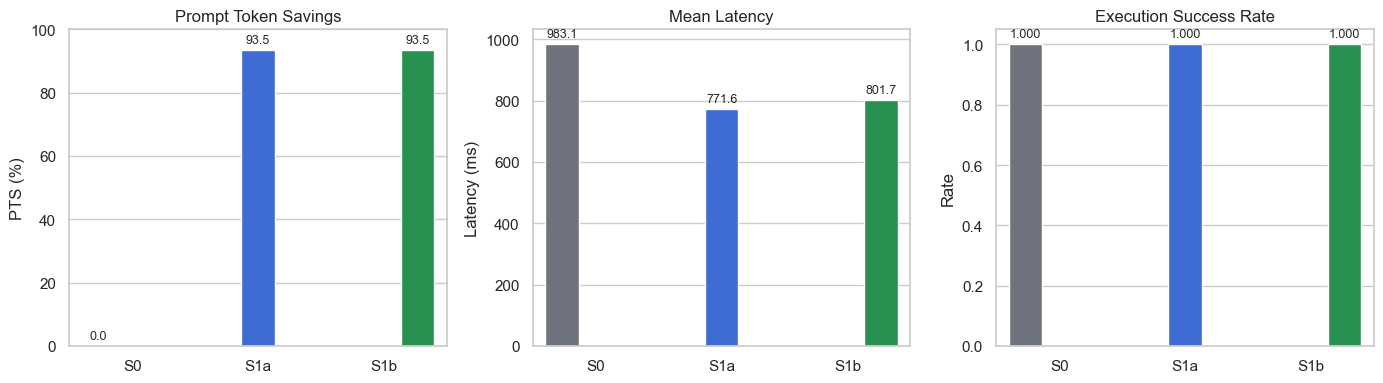

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.barplot(data=condition_metrics, x="condition", y="pts", hue="condition", palette=palette, legend=False, ax=axes[0])
axes[0].set_title("Prompt Token Savings")
axes[0].set_xlabel("")
axes[0].set_ylabel("PTS (%)")
axes[0].set_ylim(0, 100)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.1f", padding=3, fontsize=9)

sns.barplot(data=condition_metrics, x="condition", y="latency_ms", hue="condition", palette=palette, legend=False, ax=axes[1])
axes[1].set_title("Mean Latency")
axes[1].set_xlabel("")
axes[1].set_ylabel("Latency (ms)")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f", padding=3, fontsize=9)

sns.barplot(data=condition_metrics, x="condition", y="execution_success_rate", hue="condition", palette=palette, legend=False, ax=axes[2])
axes[2].set_title("Execution Success Rate")
axes[2].set_xlabel("")
axes[2].set_ylabel("Rate")
axes[2].set_ylim(0, 1.05)
for container in axes[2].containers:
    axes[2].bar_label(container, fmt="%.3f", padding=3, fontsize=9)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "exp3_efficiency_runtime.png", dpi=200, bbox_inches="tight")
plt.show()

## Paired Condition Deltas

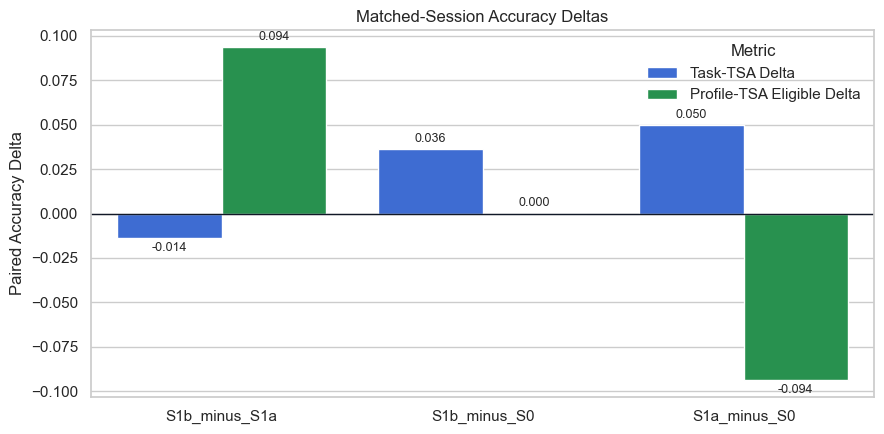

In [7]:
delta_long = paired_df.melt(
    id_vars="comparison",
    value_vars=["task_tsa_delta", "profile_tsa_eligible_delta"],
    var_name="metric",
    value_name="delta",
)
delta_long["metric"] = delta_long["metric"].map({
    "task_tsa_delta": "Task-TSA Delta",
    "profile_tsa_eligible_delta": "Profile-TSA Eligible Delta",
})

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=delta_long, x="comparison", y="delta", hue="metric", ax=ax, palette=["#2563EB", "#16A34A"])
ax.axhline(0, color="#111827", linewidth=1)
ax.set_xlabel("")
ax.set_ylabel("Paired Accuracy Delta")
ax.set_title("Matched-Session Accuracy Deltas")
ax.legend(title="Metric", frameon=False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=9)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "exp3_paired_accuracy_deltas.png", dpi=200, bbox_inches="tight")
plt.show()

## Tool-Level Task-TSA

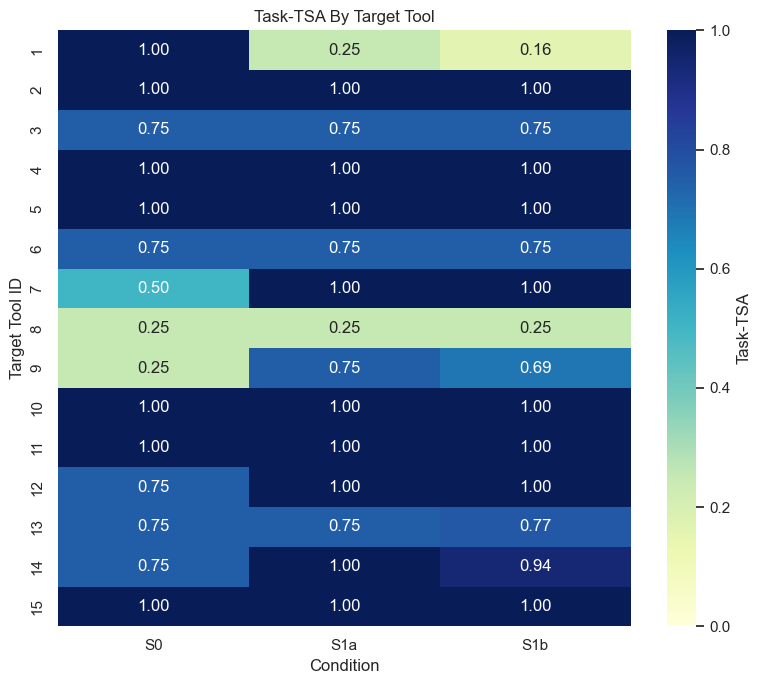

,condition,task_optimal_tool_id,task_tsa,n
0,S0,1,1.000,64
1,S0,2,1.000,64
2,S0,3,0.750,64
3,S0,4,1.000,64
4,S0,5,1.000,64
5,S0,6,0.750,64
6,S0,7,0.500,64
7,S0,8,0.250,64
8,S0,9,0.250,64
9,S0,10,1.000,64


In [8]:
tool_acc = (
    sessions.groupby(["condition", "task_optimal_tool_id"], observed=True)
    .agg(task_tsa=("task_tsa_hit", "mean"), n=("session_id", "count"))
    .reset_index()
)

pivot_tool = tool_acc.pivot(index="task_optimal_tool_id", columns="condition", values="task_tsa").reindex(columns=condition_order)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(pivot_tool, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1, cbar_kws={"label": "Task-TSA"}, ax=ax)
ax.set_xlabel("Condition")
ax.set_ylabel("Target Tool ID")
ax.set_title("Task-TSA By Target Tool")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "exp3_tool_level_task_tsa.png", dpi=200, bbox_inches="tight")
plt.show()

display(tool_acc.sort_values(["condition", "task_optimal_tool_id"]).round(3))

## Selected Tool Distribution

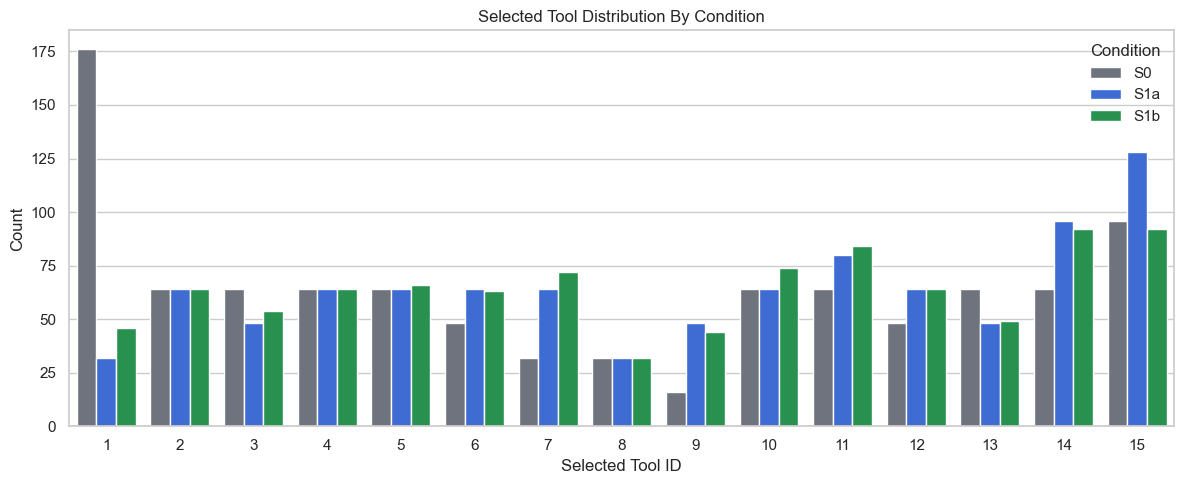

In [9]:
selection_counts = (
    sessions.groupby(["condition", "selected_tool_id"], observed=True)
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=selection_counts, x="selected_tool_id", y="count", hue="condition", palette=palette, ax=ax)
ax.set_xlabel("Selected Tool ID")
ax.set_ylabel("Count")
ax.set_title("Selected Tool Distribution By Condition")
ax.legend(title="Condition", frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "exp3_selected_tool_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## Thesis-Safe Interpretation

In [10]:
s0 = condition_metrics.set_index("condition").loc["S0"]
s1a = condition_metrics.set_index("condition").loc["S1a"]
s1b = condition_metrics.set_index("condition").loc["S1b"]

summary = f"""
Exp3-Core completed successfully with {len(sessions):,} sessions and {sessions['session_id'].nunique():,} matched question-profile cases.

Primary result: S1a achieved the highest Task-TSA ({s1a.task_tsa:.3f}), followed by S1b ({s1b.task_tsa:.3f}) and S0 ({s0.task_tsa:.3f}). Therefore, the final report should not claim that FSLSM conditioning improves overall task-based tool selection accuracy relative to unconditioned RAG-MCP.

Efficiency result: both RAG-MCP conditions achieved large prompt token savings relative to S0: S1a PTS = {s1a.pts:.1f}% and S1b PTS = {s1b.pts:.1f}%.

Secondary personalization result: S1b improved over S1a on Profile-TSA Eligible by {paired_df.set_index('comparison').loc['S1b_minus_S1a', 'profile_tsa_eligible_delta']:.3f}, indicating a limited profile-conditioned benefit on the subset where profile-specific tool labels are meaningful.

Runtime validity: all conditions reached execution_success_rate = {s0.execution_success_rate:.3f}, and grounded output rate was consistent across conditions.
"""
print(summary)


Exp3-Core completed successfully with 2,880 sessions and 960 matched question-profile cases.

Primary result: S1a achieved the highest Task-TSA (0.833), followed by S1b (0.820) and S0 (0.783). Therefore, the final report should not claim that FSLSM conditioning improves overall task-based tool selection accuracy relative to unconditioned RAG-MCP.

Efficiency result: both RAG-MCP conditions achieved large prompt token savings relative to S0: S1a PTS = 93.5% and S1b PTS = 93.5%.

Secondary personalization result: S1b improved over S1a on Profile-TSA Eligible by 0.094, indicating a limited profile-conditioned benefit on the subset where profile-specific tool labels are meaningful.

Runtime validity: all conditions reached execution_success_rate = 1.000, and grounded output rate was consistent across conditions.

